#### DRW - Crypto Market Prediction

Develop a model capable of predicting crypto future price movements.

Link to the competition: https://www.kaggle.com/competitions/drw-crypto-market-prediction/overview

The evaluation metric is: Pearson correlation coefficient (PCC)

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from xgboost import XGBRegressor
import xgboost as xgb
from scipy.stats import pearsonr

In [2]:
data_path = "/home/yang/team_kaggle/drw/data"

In [3]:
data = pd.read_parquet(Path(data_path, "train.parquet"))
training_split = int(len(data) * 0.9)
training_data = data[:training_split].copy(deep=True).sample(frac=1.0, random_state=42)
training_data.head(10)

,bid_qty,ask_qty,buy_qty,sell_qty,volume,X1,X2,X3,X4,X5,...,X772,X773,X774,X775,X776,X777,X778,X779,X780,label
2023-09-22 13:48:00,30.451,9.587,131.008,240.577,371.585,0.613908,-0.105061,0.152013,0.358002,0.581303,...,0.237893,0.001721,-0.703532,-0.717516,-0.731666,-0.750787,-0.784835,-0.845109,-1.026671,0.404147
2023-06-05 13:43:00,12.546,9.052,177.254,103.339,280.593,-1.294444,-1.065445,-1.519187,-1.307257,-1.027440,...,0.234314,0.003040,-0.703493,-0.717321,-0.731407,-0.749947,-0.638066,-0.198370,0.401746,-2.288958
2023-03-03 21:08:00,28.115,1.846,64.046,92.153,156.199,0.538541,1.384021,1.326621,1.278617,1.114203,...,0.361685,0.012305,-0.703534,-0.717539,-0.731713,-0.751212,-0.803651,-0.874355,-1.061862,-0.198246
2023-03-21 14:28:00,16.587,6.481,685.533,516.659,1202.192,-1.075066,-2.425801,-1.779769,-1.400204,-1.143276,...,0.210044,-0.068912,-0.703419,-0.717341,-0.731342,-0.750352,-0.784201,-0.758888,-0.496243,1.066113
2023-10-06 14:12:00,7.754,15.786,208.633,64.463,273.096,-0.394306,-0.265268,-0.244435,-0.200905,-0.143482,...,0.217076,-0.023617,-0.703534,-0.717499,-0.731617,-0.750767,-0.786556,-0.847332,-1.029312,2.976464
2024-01-08 22:59:00,1.289,3.143,23.820,20.168,43.988,-0.232186,0.058145,-0.067275,-0.180023,-0.222768,...,-0.040235,-0.081511,1.513897,1.224635,0.710635,0.169551,-0.376722,-0.300253,0.177083,-0.476952
2023-11-16 16:40:00,12.954,0.515,35.340,31.386,66.726,-0.872672,-0.427200,-0.340132,-0.504263,-0.833295,...,0.062254,-0.018125,-0.703529,-0.717507,-0.731650,-0.750939,-0.792409,-0.854032,-0.992407,-1.564496
2023-03-03 08:29:00,18.877,8.205,14.801,40.131,54.932,-0.186218,-0.111027,-0.197238,-0.194886,-0.158493,...,0.358917,0.007322,-0.703312,-0.717099,-0.730852,-0.741579,-0.729025,-0.793536,-0.979160,0.142196
2023-03-09 02:33:00,24.134,1.607,64.197,130.388,194.585,-1.085906,0.564185,0.079430,-0.173524,-0.486576,...,0.380009,0.001849,-0.702115,-0.714585,-0.687458,-0.590716,-0.589875,-0.711809,-0.841042,-0.151750
2023-11-26 12:36:00,7.842,5.550,149.639,105.303,254.942,-1.367345,-1.586307,-2.781514,-3.104900,-3.110723,...,0.050912,-0.008690,1.238179,1.263109,1.288414,1.323457,1.434223,1.551151,1.583252,-0.618995


In [4]:
validation_data = data[training_split:].copy(deep=True).sample(frac=1.0, random_state=42)
validation_data.head(10)

,bid_qty,ask_qty,buy_qty,sell_qty,volume,X1,X2,X3,X4,X5,...,X772,X773,X774,X775,X776,X777,X778,X779,X780,label
2024-02-15 19:59:00,2.629,4.574,77.560,61.259,138.819,-0.916808,-0.080693,-0.992057,-1.244708,-1.189084,...,-0.075227,-0.032760,-0.703521,-0.717524,-0.731710,-0.751194,-0.801567,-0.869344,-1.016478,-1.420728
2024-02-04 10:26:00,8.230,5.317,12.894,19.355,32.249,0.027582,0.941362,0.723948,0.232031,-0.137367,...,-0.005159,-0.004962,1.522358,1.552987,1.584072,1.627103,1.759489,1.853831,1.768100,0.767265
2024-02-21 01:38:00,0.048,8.074,1.816,28.164,29.980,1.041465,0.499925,0.936520,1.264501,1.556783,...,-0.075917,-0.007578,-0.703353,-0.707017,-0.631882,-0.517108,-0.559903,-0.604274,-0.468075,-0.267389
2024-02-18 17:18:00,3.099,5.416,22.556,33.268,55.824,-0.806286,0.102591,-0.128052,-0.308196,-0.525426,...,-0.074251,-0.011798,1.517356,1.547885,1.578868,1.621758,1.757768,1.907617,1.959137,-0.134264
2024-02-12 17:04:00,2.542,2.996,450.135,170.333,620.468,-0.774916,-1.822263,-0.875055,-0.385478,-0.314361,...,-0.059810,-0.039327,-0.703483,-0.717431,-0.731558,-0.750359,-0.679877,-0.273022,0.369030,1.395515
2024-02-24 12:18:00,1.214,18.511,6.504,37.793,44.297,-1.944382,-1.425486,-1.096297,-0.830163,-0.605446,...,-0.069264,0.000372,1.366647,1.394153,1.422070,1.458937,1.363744,0.977184,0.446138,0.103424
2024-02-03 06:39:00,2.942,15.523,8.706,33.359,42.065,1.202853,0.257074,0.521117,0.716639,0.905002,...,-0.007140,-0.008129,1.522358,1.552987,1.583637,1.595059,1.156184,0.595505,0.031638,-0.024143
2024-02-10 17:53:00,9.455,8.785,9.796,12.434,22.230,0.661490,-0.389266,-0.196680,0.070993,0.264762,...,-0.041637,-0.032277,1.521669,1.552283,1.583355,1.626246,1.670783,1.443523,0.978250,1.078469
2024-02-27 18:54:00,4.216,4.030,40.594,50.865,91.459,-1.177479,-0.593777,-0.965681,-1.089546,-1.129838,...,-0.104259,-0.041865,-0.703515,-0.717522,-0.731691,-0.751106,-0.797309,-0.798410,-0.587085,-0.024443
2024-02-16 20:36:00,8.907,0.305,21.338,17.482,38.820,0.629328,-0.420924,-0.317750,-0.128818,0.076339,...,-0.074030,-0.020025,-0.703551,-0.717554,-0.731736,-0.751237,-0.802883,-0.872844,-1.059787,0.411006


In [5]:
del data

In [6]:
# create new features to capture market microstructure dynamics
def new_features(df):
    #feature_pool = ["bid_ask_interaction", "bid_buy_interaction", "bid_sell_interaction", "ask_buy_interaction", "ask_sell_interaction", "buy_sell_interaction"]
    # Create interaction features for df
    feature_pool = ["buy_sell_interaction"]
    # df['bid_ask_interaction'] = df['bid_qty'] * df['ask_qty']
    # df['bid_buy_interaction'] = df['bid_qty'] * df['buy_qty']
    # df['bid_sell_interaction'] = df['bid_qty'] * df['sell_qty']
    # df['ask_buy_interaction'] = df['ask_qty'] * df['buy_qty']
    # df['ask_sell_interaction'] = df['ask_qty'] * df['sell_qty']
    df['buy_sell_interaction'] = df['buy_qty'] * df['sell_qty']
    # Add more features if needed
    # df['volume_weighted_sell'] = df['sell_qty'] * df['volume']
    # df['buy_sell_ratio'] = df['buy_qty'] / (df['sell_qty'] + 1e-8)
    # df['selling_pressure'] = df['sell_qty'] / (df['volume'] + 1e-8)
    # df['effective_spread_proxy'] = np.abs(df['buy_qty'] - df['sell_qty']) / (df['volume'] + 1e-8)
    return df, feature_pool

In [7]:
training_data_with_inter_features, feature_pool = new_features(training_data)
validation_data_with_inter_features, _ = new_features(validation_data)

In [8]:
#train_feature_list = training_data.columns[:-2]  # Exclude 'label' and 'timestamp'

# train_feature_list = [
#     "X344", "X598", "X862", "X385", "X852", "X603", "X860", "X674",
#     "X415", "X345", "X137", "X855", "X174", "X302", "X178", "X532", "X168", "X612",
#     "bid_qty", "ask_qty", "buy_qty", "sell_qty", "volume"
# ]

# train_feature_list = ["X40", "X137", "X168", "X169", "X173", "X174", "X178", "X179", "X197", "X198",
#                       "X302", "X333", "X345", "X385", "X415", "X421", "X598", "X603", "X612", "X674",
#                        "buy_qty", "sell_qty", "volume"]

# train_feature_list = [ "X137", "X173", "X174", "X178", "X179", "X197", "X198",
#                       "X302", "X333", "X345", "X385", "X415", "X421", "X603", "X612", "X674",]

train_feature_list = ["X40", "X137", "X168", "X169", "X173", "X174", "X178", "X179", "X197", "X198",
                      "X302", "X333", "X345", "X385", "X415", "X421", "X598", "X603", "X612", "X674",
                       "buy_qty", "sell_qty", "volume", 'X647', 'X547', 'X517', 'X716', 'X640']

In [9]:
X_train = training_data_with_inter_features[train_feature_list + feature_pool]
y_train = training_data_with_inter_features["label"]
X_valid = validation_data_with_inter_features[train_feature_list + feature_pool]
y_valid = validation_data_with_inter_features["label"]

In [10]:
xgb_params = {
    "tree_method": "hist",
    "colsample_bylevel": 0.4778015829774066,
    "colsample_bynode": 0.362764358742407,
    "colsample_bytree": 0.7107423488010493,
    "gamma": 1.7094857725240398,
    "learning_rate": 0.02213323588455387,
    "max_depth": 20,
    "max_leaves": 12,
    "min_child_weight": 16,
    "n_estimators": 1667,
    "n_jobs": -1,
    "random_state": 42,
    "reg_alpha": 39.352415706891264,
    "reg_lambda": 75.44843704068275,
    "subsample": 0.06566669853471274,
    "verbosity": 0,
    "early_stopping_rounds":25
}

In [11]:
model = XGBRegressor()
#model = XGBRegressor(**xgb_params)

model.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        verbose=100,
    )

[0]	validation_0-rmse:1.04941
[99]	validation_0-rmse:1.13823


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [12]:
y_pred = model.predict(X_valid)

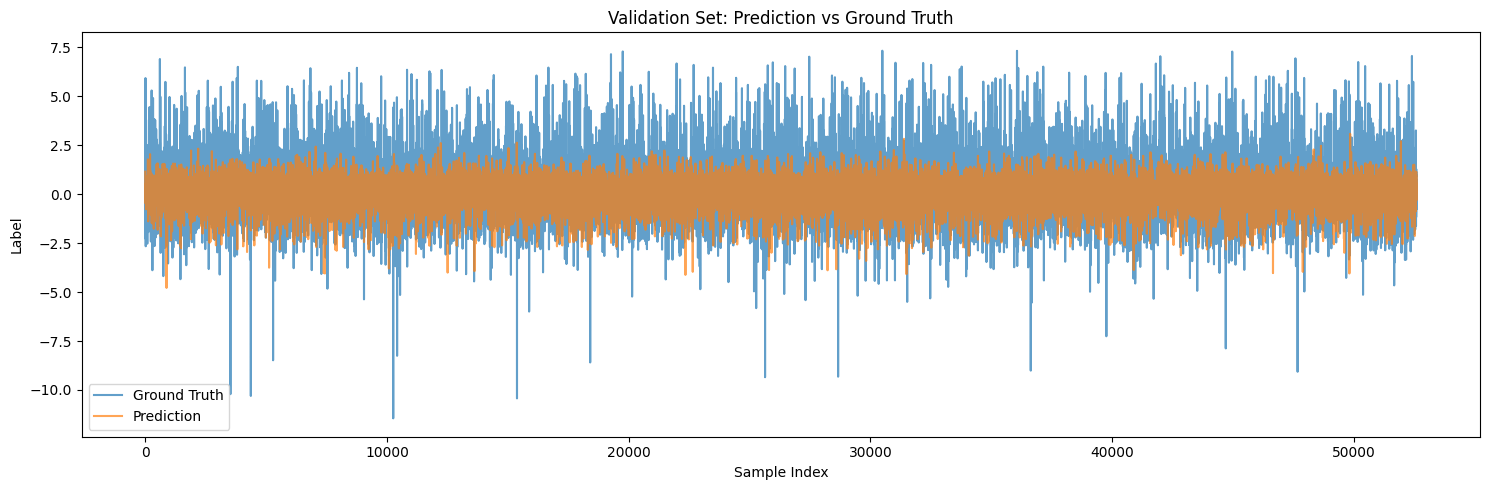

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.plot(y_valid.to_numpy().flatten(), label='Ground Truth', alpha=0.7)
plt.plot(y_pred, label='Prediction', alpha=0.7)
plt.title('Validation Set: Prediction vs Ground Truth')
plt.xlabel('Sample Index')
plt.ylabel('Label')
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
from scipy.stats import pearsonr

# Calculate Pearson correlation coefficient
pcc, _ = pearsonr(y_valid.to_numpy().flatten(), y_pred)
print("Pearson correlation coefficient (PCC):", pcc)

Pearson correlation coefficient (PCC): 0.04570013247942397


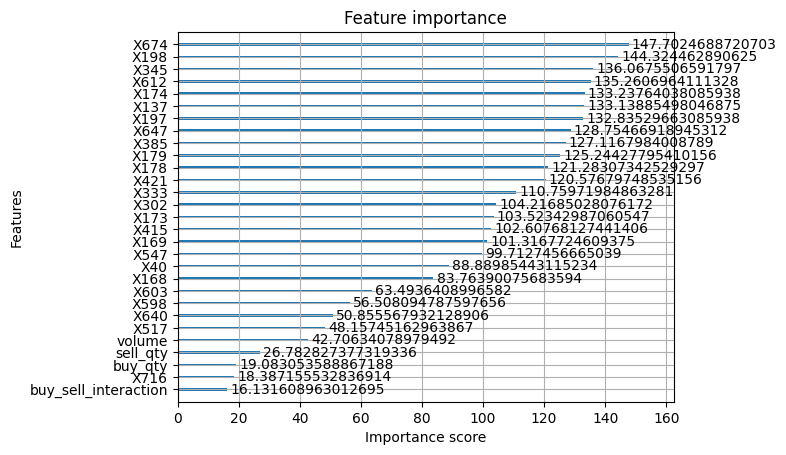

In [15]:
xgb.plot_importance(model, importance_type='gain')
plt.show()

In [16]:
testing_data = pd.read_parquet(Path(data_path, "test.parquet"))
testing_data = testing_data.drop(columns=["label"])
testing_data.head(10)

,bid_qty,ask_qty,buy_qty,sell_qty,volume,X1,X2,X3,X4,X5,...,X771,X772,X773,X774,X775,X776,X777,X778,X779,X780
ID,,,,,,,,,,,,,,,,,,,,,
1,0.317,8.102,13.164,10.272,23.436,-0.341229,0.041851,-0.020094,-0.206221,-0.297124,...,-0.525974,-0.147911,-0.043417,1.521787,1.548965,1.495735,1.166730,0.281056,-0.187831,-0.599553
2,2.608,2.111,123.562,40.163,163.725,-1.029564,-1.382505,-1.214935,-1.020241,-0.960397,...,-0.340076,-0.126703,-0.077090,-0.703054,-0.716951,-0.721292,-0.674619,-0.639318,-0.736268,-0.862220
3,2.768,10.787,126.137,118.266,244.403,-2.594090,-5.486158,-4.744466,-3.930152,-3.275324,...,2.131345,-0.147750,-0.030627,-0.703514,-0.717525,-0.731701,-0.750998,-0.789366,-0.850941,-1.033131
4,0.948,12.157,16.069,31.723,47.792,0.240745,0.997585,1.028965,1.081052,0.811895,...,0.524579,-0.136737,-0.033380,1.521167,1.551771,1.582833,1.625830,1.762155,1.911924,1.962445
5,1.084,3.493,32.679,37.327,70.006,0.067189,0.772852,0.772152,0.714846,0.514422,...,-0.523453,-0.218991,-0.004915,-0.703161,-0.716900,-0.714699,-0.652209,-0.623165,-0.699887,-0.640094
6,0.791,7.437,22.597,12.342,34.939,-0.202193,-0.431540,-0.525282,-0.586427,-0.630476,...,-0.353245,-0.198320,-0.085736,1.523340,1.553988,1.584628,1.595013,1.150255,0.588374,0.024996
7,2.296,1.195,176.867,78.398,255.265,1.090759,-0.909704,-0.204441,0.142584,0.358128,...,0.363553,-0.219176,-0.066952,-0.703419,-0.717470,-0.731672,-0.751103,-0.723096,-0.381238,0.235638
8,11.111,12.663,14.508,19.957,34.465,1.306755,0.818914,1.558436,1.734842,1.694095,...,0.271059,-0.227175,-0.022281,-0.703531,-0.717535,-0.731715,-0.751181,-0.798122,-0.864106,-1.048633
9,2.729,4.766,30.114,7.165,37.279,-0.006084,-0.364601,-0.197368,0.021197,0.117522,...,-0.042336,-0.235899,-0.052247,1.523294,1.553927,1.579491,1.513038,0.832172,0.263215,-0.253831


In [17]:
testing_data_with_inter_features, _ = new_features(testing_data)

In [18]:
predictions = model.predict(testing_data_with_inter_features[train_feature_list + feature_pool])

# prepare submission DataFrame
submission_df = pd.DataFrame({
    "ID": np.arange(1, len(predictions)+1),
    "prediction": predictions
})
submission_df.to_csv("submission.csv", index=False)
submission_df

,ID,prediction
0,1,-0.732964
1,2,-0.273251
2,3,0.131723
3,4,0.259287
4,5,-1.355091
...,...,...
538145,538146,1.010727
538146,538147,0.325200
538147,538148,-1.818227
538148,538149,-0.474696


In [19]:
sample_submission = pd.read_csv(Path(data_path, "sample_submission.csv"))
sample_submission.head(10)

,ID,prediction
0,1,-0.280233
1,2,1.371969
2,3,-2.045252
3,4,-1.447555
4,5,-1.303901
5,6,1.659284
6,7,1.376758
7,8,0.237542
8,9,-0.101127
9,10,1.267094
